In [1]:
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import root_mean_squared_error
import os
os.chdir("C:/Users/PGCP-AI/ML/MachineLearning/Datasets")

In [2]:
df = pd.read_csv('gdp-per-capita-ppp-constant-2011.csv')
df.columns

Index(['Year', 'GDP_per_capita'], dtype='object')

In [3]:
result = adfuller(df['GDP_per_capita'], maxlag=10)
print("P-Value =", result[1])
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value = 1.0
Time Series is not Stationary


In [4]:
diff = df["GDP_per_capita"].diff().iloc[1:]
diff1 = diff.diff().iloc[1:]
result = adfuller(diff1,maxlag=5)
print("P-Value =", result[1])
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value = 1.7937394655159275e-05
Time Series is Stationary


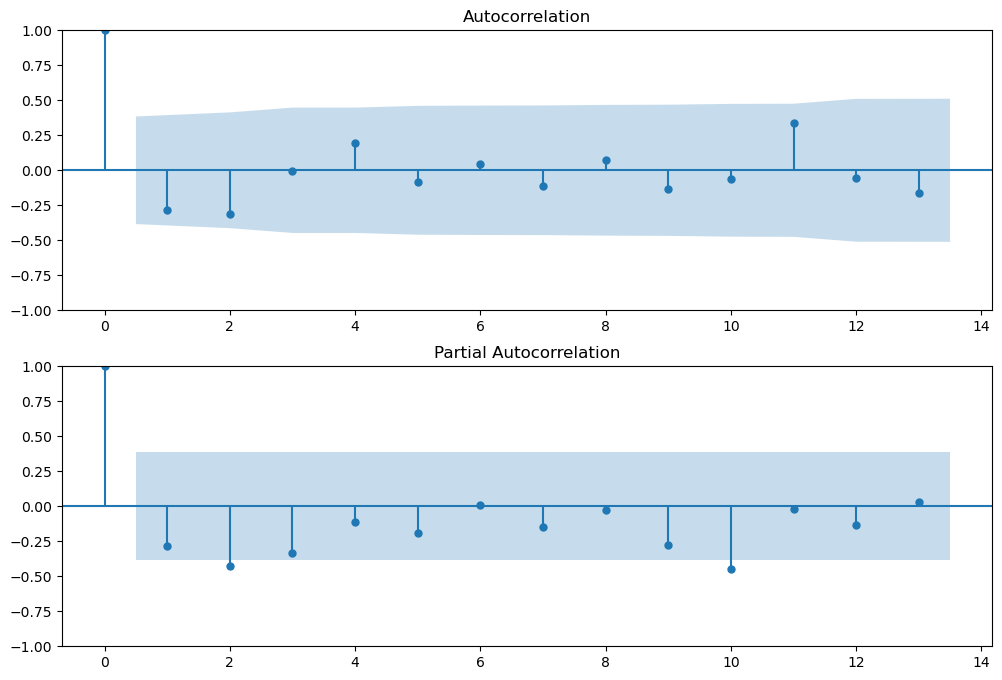

In [5]:
fig, ax = plt.subplots(2, 1, figsize = (12,8))
plot_acf(diff1, ax = ax[0])
plot_pacf(diff1, ax = ax[1])
plt.show()

In [6]:
y_train = df['GDP_per_capita'].iloc[:-4]
y_test = df['GDP_per_capita'].iloc[-4:]

In [14]:
model = ARIMA(y_train, order = (1,2,1))
model_fit = model.fit()

In [15]:
predictions = model_fit.predict(start = len(y_train), end = len(y_train) + len(y_test) -1, dynamic = False)
rmse = root_mean_squared_error(y_test, predictions)

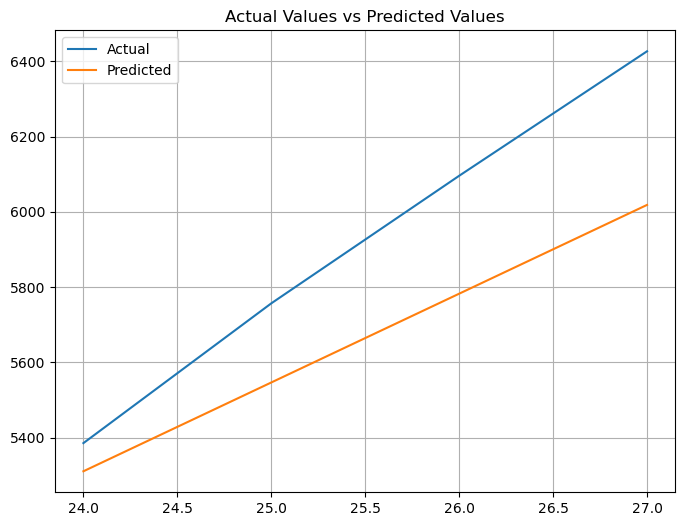

In [16]:
plt.figure(figsize=(8,6))
plt.plot(df['GDP_per_capita'][-4:],label='Actual')
plt.plot(predictions,label='Predicted')
plt.title('Actual Values vs Predicted Values')
plt.legend()
plt.grid()
plt.show()

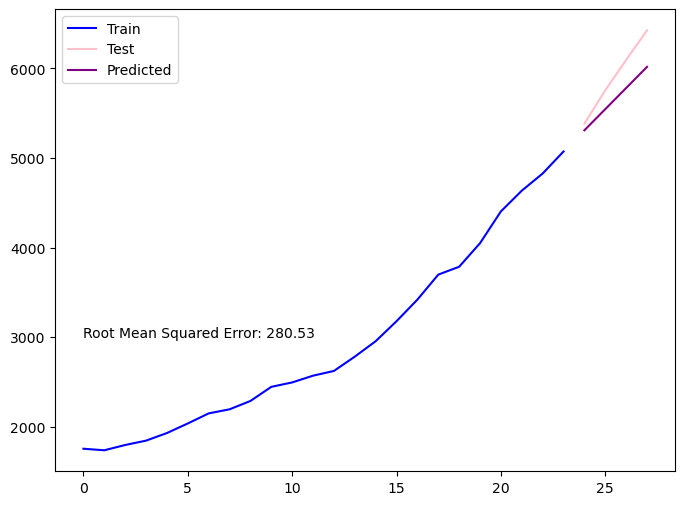

In [17]:
plt.figure(figsize=(8,6))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink',label='Test')
predictions.plot(color='purple',label='Predicted')
plt.text(0,3000,f"Root Mean Squared Error: {rmse:.2f}")
plt.legend()
plt.show()

In [11]:
from pmdarima.arima import auto_arima

In [12]:
model = auto_arima(y_train, trace = True, error_Action = 'ignore', suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=258.459, Time=0.11 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=257.580, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=257.347, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=254.331, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=256.274, Time=0.06 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=256.186, Time=0.04 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=257.938, Time=0.07 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec

Best model:  ARIMA(0,2,1)(0,0,0)[0]          
Total fit time: 0.399 seconds


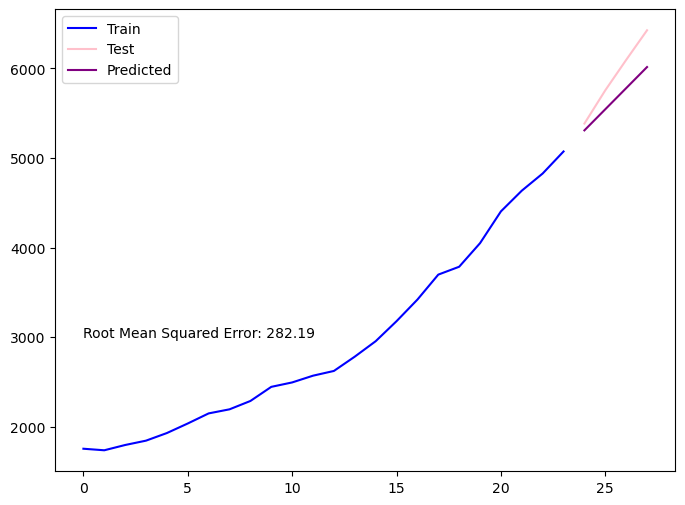

In [13]:
forecast_auto =  model.predict(n_periods=len(y_test))
plt.figure(figsize=(8,6))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink',label='Test')
forecast_auto.plot(color='purple',label='Predicted')
plt.text(0,3000,f"Root Mean Squared Error: {root_mean_squared_error(y_test,forecast_auto):.2f}")
plt.legend()
plt.show()

In [18]:
import sktime
sktime.__version__

'0.40.1'